# 03 — Infrastructure Proxy Generation

Create the three components of the **Infrastructure Fragility (I_F)** sub-index:

| Component | Proxy Data | Weight |
|-----------|-----------|--------|
| Tower Density | HIFLD Cellular Towers | 0.30 |
| Broadband Latency | Ookla avg_lat_ms | 0.30 |
| Road Centrality | OSMnx betweenness | 0.40 |

**Normalization:** Z-score with CDF mapping to [0, 1].  
**Missing data:** Uniform median imputation for all components.  
**Edge assignment:** Road edges assigned to tracts via midpoint (avoids double-counting).

**Inputs:** `data/raw/` (towers, Ookla, road network), `data/processed/study_tracts.gpkg`  
**Outputs:** `data/processed/infra_fragility.gpkg`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    DATA_RAW, DATA_PROCESSED, CRS_PROJECT, CRS_WGS84,
    SQFT_PER_SQKM,
    W_IF_TOWER_DENSITY, W_IF_LATENCY, W_IF_ROAD_CENTRALITY,
    W_ROAD_BETWEENNESS, W_ROAD_DENSITY,
)
from src.utils import load_study_tracts, ensure_crs, z_score_normalize, impute_with_median

tracts = load_study_tracts()
print(f"Loaded {len(tracts)} tracts")

Loaded 2660 tracts


## A. Tower Density per Tract

Count HIFLD cellular towers per tract, compute density (towers/km²), and normalize.  
**Inverted normalization:** more towers → lower fragility score.

**Critical note:** EPSG:2264 units are US survey feet.  
Area conversion: `area_km² = area_sqft / 10,763,910.4`

In [2]:
towers = gpd.read_file(DATA_RAW / "hifld_cellular_towers.geojson")
towers = ensure_crs(towers)
print(f"Towers: {len(towers)}")

# Spatial join: count towers per tract
tracts_proj = ensure_crs(tracts)
joined = gpd.sjoin(
    towers, tracts_proj[["GEOID", "geometry"]],
    how="inner", predicate="within",
)
tower_counts = joined.groupby("GEOID").size().reset_index(name="tower_count")

# Compute tract areas in km² (EPSG:2264 area is in sq US survey feet)
tower_df = tracts_proj[["GEOID", "geometry"]].copy()
tower_df["area_km2"] = tower_df.geometry.area / SQFT_PER_SQKM

# Merge tower counts (tracts with no towers get 0)
tower_df = tower_df.merge(tower_counts, on="GEOID", how="left")
tower_df["tower_count"] = tower_df["tower_count"].fillna(0).astype(int)
tower_df["tower_density_km2"] = tower_df["tower_count"] / tower_df["area_km2"]

# Z-score normalize INVERTED: higher density = lower fragility
tower_df["tower_density_norm"] = z_score_normalize(
    tower_df["tower_density_km2"], invert=True
)

print(f"\nTower density stats:")
print(f"  Total towers: {tower_df['tower_count'].sum()}")
print(f"  Tracts with 0 towers: {(tower_df['tower_count'] == 0).sum()}")
print(f"  Density range: {tower_df['tower_density_km2'].min():.3f} – {tower_df['tower_density_km2'].max():.3f} towers/km²")
print(f"  Normalized range: [{tower_df['tower_density_norm'].min():.4f}, {tower_df['tower_density_norm'].max():.4f}]")
print(f"  Normalized mean: {tower_df['tower_density_norm'].mean():.4f} (should be ~0.5)")

Towers: 1275

Tower density stats:
  Total towers: 773
  Tracts with 0 towers: 2085
  Density range: 0.000 – 0.966 towers/km²
  Normalized range: [0.0000, 0.5922]
  Normalized mean: 0.5385 (should be ~0.5)


In [3]:
ookla_path = DATA_RAW / "ookla_fixed_pre_helene.gpkg"

if not ookla_path.exists():
    print(f"WARNING: {ookla_path} not found. Ookla latency will be imputed with median later.")
    ookla_tract = pd.DataFrame({"GEOID": tracts["GEOID"], "avg_latency_ms": np.nan})
else:
    ookla = gpd.read_file(ookla_path)
    print(f"Ookla tiles: {len(ookla)}")

    # Tiles are already point geometries (tile centroids), so use directly
    ookla_proj = ensure_crs(ookla)
    tracts_proj = ensure_crs(tracts)

    joined = gpd.sjoin(
        ookla_proj, tracts_proj[["GEOID", "geometry"]],
        how="inner", predicate="within",
    )

    # Test-count-weighted average latency per tract
    def weighted_stats(group):
        weights = group["tests"]
        if weights.sum() == 0:
            return pd.Series({
                "avg_latency_ms": np.nan,
                "total_tests": 0,
                "total_devices": 0,
                "tile_count": len(group),
            })
        return pd.Series({
            "avg_latency_ms": np.average(group["avg_lat_ms"], weights=weights),
            "total_tests": weights.sum(),
            "total_devices": group["devices"].sum(),
            "tile_count": len(group),
        })

    ookla_tract = joined.groupby("GEOID").apply(weighted_stats).reset_index()

    print(f"\nOokla per-tract stats:")
    print(f"  Tracts with Ookla data: {len(ookla_tract)}")
    print(f"  Tracts WITHOUT Ookla data: {len(tracts) - len(ookla_tract)}")
    print(f"  Latency range: {ookla_tract['avg_latency_ms'].min():.1f} – {ookla_tract['avg_latency_ms'].max():.1f} ms")

# Z-score normalize latency (higher = more fragile, no inversion)
if "avg_latency_ms" in ookla_tract.columns and ookla_tract["avg_latency_ms"].notna().any():
    ookla_tract["latency_norm"] = z_score_normalize(ookla_tract["avg_latency_ms"])
else:
    ookla_tract["latency_norm"] = np.nan

print("Ookla component ready.")

Ookla tiles: 123435



Ookla per-tract stats:
  Tracts with Ookla data: 2652
  Tracts WITHOUT Ookla data: 8
  Latency range: 1.7 – 627.2 ms
Ookla component ready.


/var/folders/wt/xrjyd8kd5fdf2d3yq0pnj06c0000gn/T/ipykernel_5018/840460041.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ookla_tract = joined.groupby("GEOID").apply(weighted_stats).reset_index()


## B. Broadband Latency per Tract (Ookla)

Spatial join Ookla tile centroids to tracts, compute test-count-weighted average latency.  
**Z-score normalization:** higher latency → higher fragility score (no inversion).  
Tracts with no Ookla tiles will be imputed with study area median.

In [4]:
# Ookla latency component already computed in cell above (from .gpkg)
# This cell intentionally left as a placeholder — the stale .parquet code path has been removed.
print(f"Ookla tract data: {len(ookla_tract)} tracts with latency data")

Ookla tract data: 2652 tracts with latency data


## C. Road Network Centrality / Route Redundancy

Compute edge betweenness centrality on the road network to identify single-points-of-failure.  
Uses **approximate** betweenness (`k=500` sample nodes) to keep computation under 10 minutes.

Per tract, we compute:
- `max_betweenness`: highest-centrality road segment (SPOF risk)
- `road_density`: edge count / total road length (redundancy measure)

**Road fragility** = 0.60 × norm(max_betweenness) + 0.40 × norm_inv(road_density)

In [5]:
import osmnx as ox
import networkx as nx

graph_path = DATA_RAW / "nc_road_network.graphml"

if not graph_path.exists():
    print(f"WARNING: {graph_path} not found. Road component will be imputed with median later.")
    road_stats = pd.DataFrame({"GEOID": tracts["GEOID"], "road_fragility": np.nan})
else:
    G = ox.load_graphml(str(graph_path))
    print(f"Road network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Road network: 648,424 nodes, 1,528,603 edges


In [6]:
%%time

if graph_path.exists():
    # Approximate edge betweenness centrality (k=500 sample nodes)
    k_samples = min(500, G.number_of_nodes())
    print(f"Computing approximate edge betweenness centrality (k={k_samples})...")
    print(f"  Network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    print(f"  Expected runtime: ~2 hours for statewide NC network.")
    print(f"  Started at {pd.Timestamp.now()}")

    edge_bc = nx.edge_betweenness_centrality(G, weight="length", k=k_samples)
    nx.set_edge_attributes(G, edge_bc, "betweenness")

    print(f"Done at {pd.Timestamp.now()}.")
    print(f"Betweenness values range: "
          f"{min(edge_bc.values()):.6f} – {max(edge_bc.values()):.6f}")

Computing approximate edge betweenness centrality (k=500)...


  Network: 648,424 nodes, 1,528,603 edges
  Expected runtime: ~2 hours for statewide NC network.
  Started at 2026-02-10 14:56:50.879853


Done at 2026-02-10 15:33:05.799922.
Betweenness values range: 0.000000 – 0.000062
CPU times: user 34min 25s, sys: 1min 48s, total: 36min 14s
Wall time: 36min 15s


In [7]:
if graph_path.exists():
    # Convert edges to GeoDataFrame
    edges = ox.graph_to_gdfs(G, nodes=False)
    edges = ensure_crs(edges)
    tracts_proj = ensure_crs(tracts)

    # EDGE MIDPOINT FIX: assign each edge to exactly one tract via its midpoint.
    # This avoids double-counting edges that cross tract boundaries.
    # interpolate(0.5, normalized=True) gives the point at 50% along the LineString,
    # guaranteed to lie on the line itself (unlike .centroid which can fall outside curved roads).
    edge_midpoints = edges[["geometry", "betweenness", "length"]].copy()
    edge_midpoints["geometry"] = edges.geometry.interpolate(0.5, normalized=True)

    joined = gpd.sjoin(
        edge_midpoints,
        tracts_proj[["GEOID", "geometry"]],
        how="inner", predicate="within",
    )

    print(f"Edges assigned to tracts: {len(joined):,} / {len(edges):,} total edges")
    print(f"  (Edges outside all tract polygons are excluded)")

    # Aggregate per tract
    road_stats = joined.groupby("GEOID").agg(
        mean_betweenness=("betweenness", "mean"),
        max_betweenness=("betweenness", "max"),
        edge_count=("betweenness", "count"),
        total_road_length_m=("length", "sum"),  # OSMnx stores length in meters
    ).reset_index()

    # Road density: edges per km of road
    road_stats["road_density"] = (
        road_stats["edge_count"] / (road_stats["total_road_length_m"] / 1000)
    )

    # Z-score normalize components
    road_stats["centrality_norm"] = z_score_normalize(road_stats["max_betweenness"])
    road_stats["redundancy_norm"] = z_score_normalize(road_stats["road_density"], invert=True)

    # Combined road fragility
    road_stats["road_fragility"] = (
        W_ROAD_BETWEENNESS * road_stats["centrality_norm"]
        + W_ROAD_DENSITY * road_stats["redundancy_norm"]
    )

    print(f"\nRoad stats computed for {len(road_stats)} tracts")
    print(f"  Tracts without roads: {len(tracts) - len(road_stats)}")
    print(f"  Road fragility range: [{road_stats['road_fragility'].min():.4f}, {road_stats['road_fragility'].max():.4f}]")

Edges assigned to tracts: 1,528,546 / 1,528,603 total edges
  (Edges outside all tract polygons are excluded)

Road stats computed for 2655 tracts
  Tracts without roads: 5
  Road fragility range: [0.1376, 0.9821]


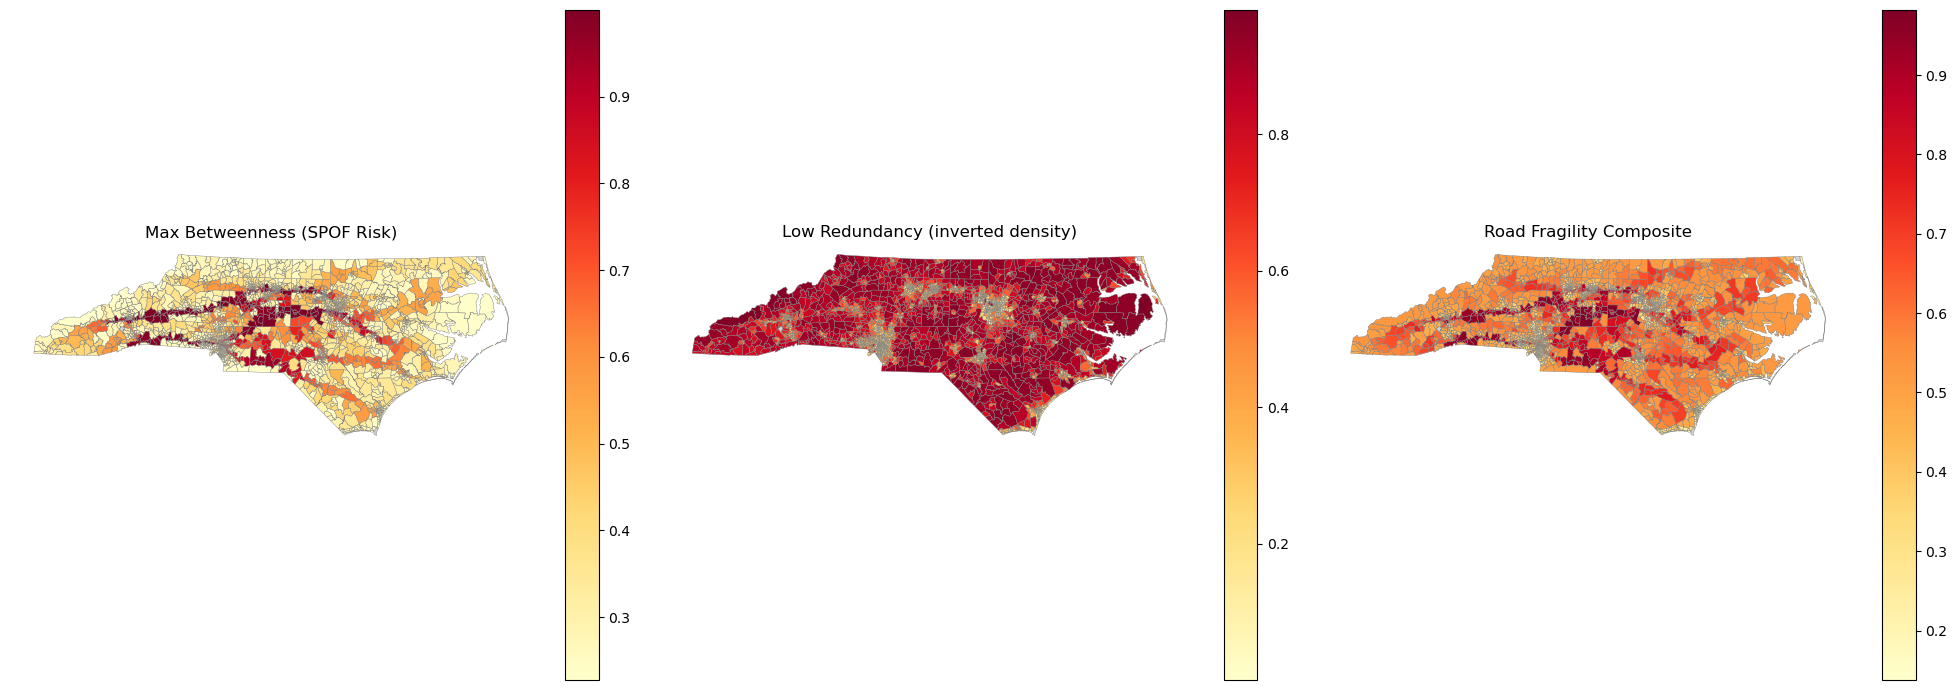

In [8]:
if graph_path.exists():
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    road_gdf = tracts_proj.merge(road_stats, on="GEOID", how="left")

    for ax, (col, title) in zip(axes, [
        ("centrality_norm", "Max Betweenness (SPOF Risk)"),
        ("redundancy_norm", "Low Redundancy (inverted density)"),
        ("road_fragility", "Road Fragility Composite"),
    ]):
        road_gdf.plot(
            column=col, ax=ax, legend=True, cmap="YlOrRd",
            edgecolor="gray", linewidth=0.3, missing_kwds={"color": "lightgray"},
        )
        ax.set_title(title)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

## Combine Infrastructure Fragility (I_F)

`I_F = 0.30 × tower_density_norm + 0.30 × latency_norm + 0.40 × road_fragility`

Missing components imputed with **study area median** (uniform strategy).

In [9]:
infra = tracts[["GEOID", "geometry"]].copy()

# Merge tower density
infra = infra.merge(
    tower_df[["GEOID", "tower_count", "tower_density_km2", "tower_density_norm"]],
    on="GEOID", how="left",
)

# Merge Ookla latency
ookla_merge_cols = ["GEOID", "latency_norm"]
if "avg_latency_ms" in ookla_tract.columns:
    ookla_merge_cols.append("avg_latency_ms")
infra = infra.merge(ookla_tract[ookla_merge_cols], on="GEOID", how="left")

# Merge road fragility
road_merge_cols = ["GEOID", "road_fragility"]
if "max_betweenness" in road_stats.columns:
    road_merge_cols.extend(["max_betweenness", "edge_count"])
infra = infra.merge(road_stats[road_merge_cols], on="GEOID", how="left")

# Uniform median imputation for all missing components
print("Imputing missing infrastructure components with study area median:")
infra, _ = impute_with_median(infra, "tower_density_norm", "Tower Density (normalized)")
infra, _ = impute_with_median(infra, "latency_norm", "Ookla Latency (normalized)")
infra, _ = impute_with_median(infra, "road_fragility", "Road Fragility")

# Composite Infrastructure Fragility
infra["I_F"] = (
    W_IF_TOWER_DENSITY * infra["tower_density_norm"]
    + W_IF_LATENCY * infra["latency_norm"]
    + W_IF_ROAD_CENTRALITY * infra["road_fragility"]
)

out_path = DATA_PROCESSED / "infra_fragility.gpkg"
infra.to_file(out_path, driver="GPKG")
print(f"\nSaved {len(infra)} tracts to {out_path}")
print(f"I_F range: [{infra['I_F'].min():.4f}, {infra['I_F'].max():.4f}]")
print(f"\nI_F distribution:")
print(infra["I_F"].describe())

Imputing missing infrastructure components with study area median:
  Imputed 8 missing values in 'Ookla Latency (normalized)' with median=0.4239
    GEOIDs: ['37077970704', '37031980100', '37091980000', '37119000102', '37063001503', '37119000301', '37089980100', '37007980000']
  Imputed 5 missing values in 'Road Fragility' with median=0.4733
    GEOIDs: ['37019020307', '37031980100', '37053110102', '37089980100', '37055970502']



Saved 2660 tracts to /Volumes/T9/Projects/HABRI/data/processed/infra_fragility.gpkg
I_F range: [0.1642, 0.8683]

I_F distribution:
count    2660.000000
mean        0.490407
std         0.108909
min         0.164214
25%         0.406605
50%         0.481850
75%         0.563746
max         0.868283
Name: I_F, dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


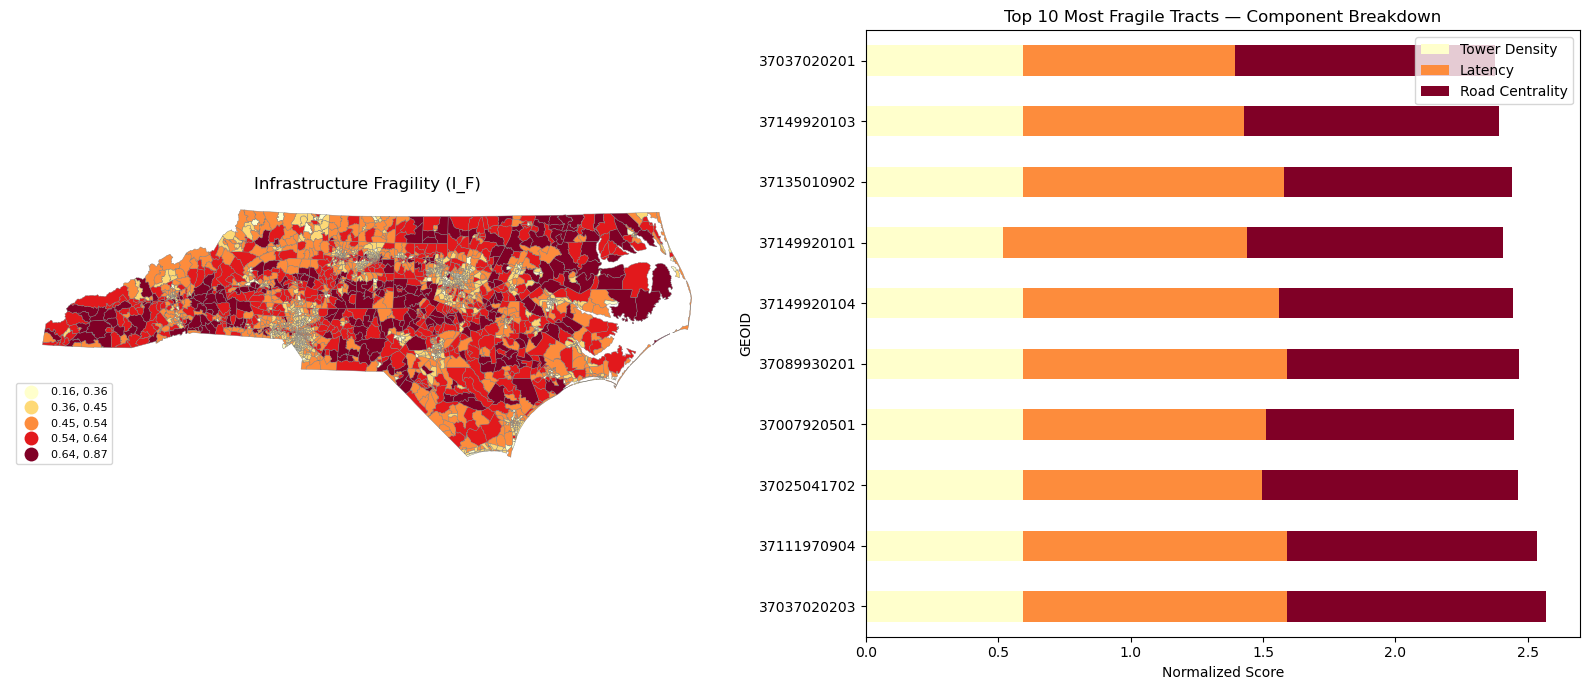

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

infra.plot(
    column="I_F", ax=axes[0], legend=True, cmap="YlOrRd",
    scheme="NaturalBreaks", k=5,
    edgecolor="gray", linewidth=0.3,
    legend_kwds={"loc": "lower left", "fontsize": 8},
)
axes[0].set_title("Infrastructure Fragility (I_F)", fontsize=12)
axes[0].set_axis_off()

# Component contribution breakdown for top 10 most fragile tracts
top10 = infra.nlargest(10, "I_F")
components = top10[["GEOID", "tower_density_norm", "latency_norm", "road_fragility"]].set_index("GEOID")
components.columns = ["Tower Density", "Latency", "Road Centrality"]
components.plot(kind="barh", stacked=True, ax=axes[1], colormap="YlOrRd")
axes[1].set_title("Top 10 Most Fragile Tracts — Component Breakdown")
axes[1].set_xlabel("Normalized Score")

plt.tight_layout()
plt.show()